# Decision Tree Pruning

| Pre-Pruning | Post-Pruning |
|------------|------------|
| Stops growth early | Grows tree first |
| Faster training | Requires additional pruning step |
| May stop useful splits | Preserves useful splits before pruning |
| Simpler implementation | Often provides better optimization |

In this notebook, we:

- Learned what Pre-Pruning is.
- Understood how pre-pruning prevents overfitting.
- Generated a non-linear classification dataset.
- Trained multiple Decision Trees with different depths.
- Compared training and testing accuracy.
- Observed how tree depth affects model complexity.

This notebook introduces techniques that stop a Decision Tree from growing excessively before it begins memorizing noise.

- Learned what Post-Pruning is.
- Trained a fully grown Decision Tree.
- Generated candidate pruning values.
- Applied Cost Complexity Pruning.
- Compared training and testing accuracy.
- Selected the optimal pruning parameter.

This notebook demonstrates how unnecessary branches can be removed after a Decision Tree has already been trained.    


## Imports
| Library | Purpose |
|----------|----------|
| NumPy (`numpy`) | Numerical computations |
| Matplotlib (`matplotlib.pyplot`) | Visualization |
| `make_moons` | Generates non-linear classification data |
| `train_test_split` | Splits dataset into training and testing sets |
| `DecisionTreeClassifier` | Builds Decision Tree models |
| `accuracy_score` | Classification evaluation |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## Generate Dataset & Train-Test Split

The Moon dataset creates two interleaving classes that are not linearly separable.
| Variable | Description |
|-----------|------------|
| `X` | Feature matrix |
| `y` | Target labels |

The dataset is divided into training and testing portions.

| Variable | Purpose |
|-----------|----------|
| `X_train` | Training features |
| `X_test` | Testing features |
| `y_train` | Training labels |
| `y_test` | Testing labels |

In [2]:
X, y = make_moons(
    n_samples=600,  # Total observations
    noise=0.25,     # Random variation added to data
    random_state=42 # Reproducible results
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Decision Tree Pre-Pruning

Pre-Pruning is a technique that limits tree growth during training.

Instead of allowing the tree to grow until every leaf becomes pure, restrictions are applied beforehand.

**Without Pre-Pruning**

```text
Root
├── Split
│   ├── Split
│   │   ├── Split
│   │   │   ├── Split
│   │   │   └── Split
│   │   └── Split
│   └── Split

Very Deep Tree
```

**With Pre-Pruning**
```text
Root
├── Split
│   ├── Leaf
│   └── Leaf
└── Leaf

Controlled Tree
```

The goal is to stop unnecessary growth before overfitting occurs.

## Max Depth (max_depth)
- We train several trees using different values of `max_depth`
- Controls how many levels the tree can grow.

| Depth | Effect |
|---------|---------|
| Small | Simpler tree |
| Large | More complex tree |

- Small Depth -> Underfitting
- Optimal Depth -> Best Generalization
- Large Depth -> Overfitting

The ideal depth usually lies between these extremes.

## Train  Pre-Pruned Trees

- A pre-pruned tree is created by restricting its depth and leaf size.
- Without restrictions, the tree may create many small branches.
- These branches often learn noise instead of meaningful patterns.
- Pre-pruning reduces this problem by limiting growth during training.

`min_samples_leaf`: Every leaf must contain at least given number of samples. This prevents creation of tiny leaves that memorize random noise.

Training and testing accuracy are recorded for comparison.

| Metric | Purpose |
|----------|----------|
| Training Accuracy | Performance on training data |
| Testing Accuracy | Performance on unseen data |

A large gap between training and testing accuracy often indicates overfitting.

In [3]:
depths=list(range(1,15))
depths

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

In [4]:
train_acc_pre=[]
test_acc_pre=[]

In [5]:
for d in depths:
    tree=DecisionTreeClassifier(
        max_depth=d,
        min_samples_leaf=5,
        random_state=42)
    
    tree.fit(X_train,y_train)
    train_pred_pre=tree.predict(X_train)
    test_pred_pre=tree.predict(X_test)
    train_acc_pre.append(accuracy_score(y_train,train_pred_pre))
    test_acc_pre.append(accuracy_score(y_test,test_pred_pre))

test_acc_pre

[0.8111111111111111,
 0.8888888888888888,
 0.8888888888888888,
 0.8888888888888888,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9,
 0.9]

## Visualization

The relationship between tree depth and accuracy can be visualized.

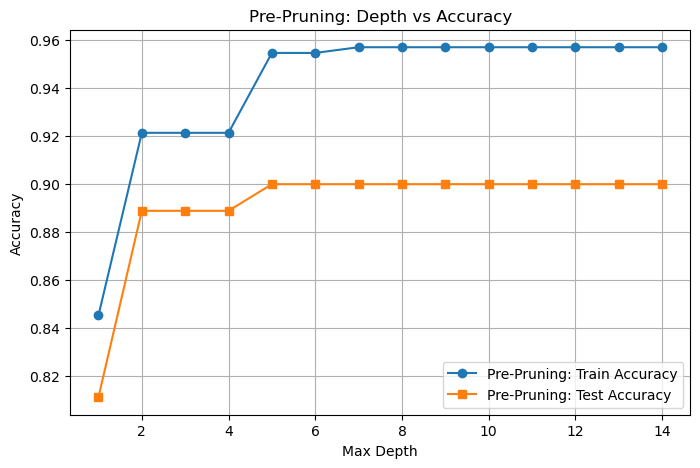

In [6]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_acc_pre, marker="o", label="Pre-Pruning: Train Accuracy")
plt.plot(depths, test_acc_pre, marker="s", label="Pre-Pruning: Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Pre-Pruning: Depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("Pre-Pruning: Depth vs Accuracy.png", dpi=100)
plt.show()

## Ideal Depth
The ideal depth is the one that achieves the highest testing accuracy.

| Function           | Purpose                              |
| ------------------ | ------------------------------------ |
| `np.argmax()`      | Returns index of maximum value       |
| `train_best_depth` | Depth with highest training accuracy |
| `test_best_depth`  | Depth with highest testing accuracy  |    

In [7]:
pre_train_best_depth=depths[np.argmax(train_acc_pre)]
pre_test_best_depth=depths[np.argmax(test_acc_pre)]
print(f"Best Depth based on training accuracy: {pre_train_best_depth}")
print(f"Best Depth based on test accuracy: {pre_test_best_depth}")

Best Depth based on training accuracy: 7
Best Depth based on test accuracy: 5


# Decision Tree Post-Pruning
- Post-Pruning is a technique that first allows a Decision Tree to grow completely and then removes branches that provide little predictive value.
- Unlike Pre-Pruning, the tree is not restricted during training.
- Instead, pruning happens afterward.


**Fully Grown Tree**
```text
Root
├── Split
│   ├── Split
│   │   ├── Split
│   │   └── Split
│   └── Split
└── Split
```

**After Pruning**
```text
Root
├── Split
│   ├── Leaf
│   └── Leaf
└── Leaf
```

The goal is to simplify the tree while maintaining strong predictive performance.

## Cost Complexity Pruning (ccp_alpha)

- Scikit-Learn uses Cost Complexity Pruning and automatically calculates possible pruning strengths.
- The peak testing accuracy often indicates the best pruning strength.
- Increasing alpha removes more branches and produces a simpler tree.

| Variable | Description |
|-----------|------------|
| `path` | Pruning information |
| `ccp_alphas` | Candidate alpha values |

- Alpha Too Small -> Complex Tree -> Less pruning
- Optimal Alpha -> Best Generalization
- Alpha Too Large -> Underfitting -> More pruning

Each alpha represents a different amount of pruning.

## Train Pruned Tree
- A Decision Tree is first trained without pruning restrictions.
- The model grows until no further useful splits can be found.
- This usually produces a highly complex tree.
- A separate Decision Tree is trained for every alpha value.
- The algorithm evaluates multiple pruning levels.

Some trees will be:

* Lightly pruned
* Moderately pruned
* Aggressively pruned

This allows us to identify the best balance between complexity and accuracy.

For every tree, we calculate:

| Metric | Purpose |
|----------|----------|
| Training Accuracy | Performance on training data |
| Testing Accuracy | Performance on unseen data |

- High and Low Training Accuracy -> Overfitting
- Similar Training and Testing Accuracy -> Good Generalization

The best pruning level usually provides strong testing performance without excessive complexity.

In [8]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas

In [10]:
train_acc_post=[]
test_acc_post=[]
for alpha in ccp_alphas:
    pruned_tree=DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42)
    pruned_tree.fit(X_train,y_train)
    train_pred=pruned_tree.predict(X_train)
    test_pred=pruned_tree.predict(X_test)
    train_acc_post.append(accuracy_score(y_train,train_pred))
    test_acc_post.append(accuracy_score(y_test,test_pred))

test_acc_post


[0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9055555555555556,
 0.9111111111111111,
 0.9111111111111111,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.9,
 0.9,
 0.9055555555555556,
 0.8888888888888888,
 0.8611111111111112,
 0.8111111111111111,
 0.49444444444444446]

## Visualization

Training and testing accuracy can be visualized against alpha values.

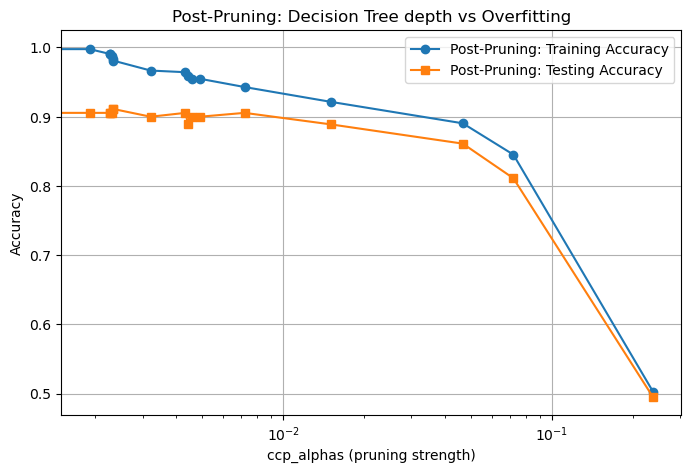

In [11]:
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas,train_acc_post, marker="o",label="Post-Pruning: Training Accuracy")
plt.plot(ccp_alphas,test_acc_post, marker="s",label="Post-Pruning: Testing Accuracy")
plt.title("Post-Pruning: Decision Tree depth vs Overfitting")
plt.xscale("log")
plt.xlabel("ccp_alphas (pruning strength)")
plt.ylabel("Accuracy")
plt.savefig("Post-Pruning: Decision Tree CCP_ALphas vs Accuracy.png",dpi=100)
plt.grid(True)
plt.legend()
plt.show()    

## Ideal Alpha
The optimal alpha can be chosen based on accuracy.

| Function           | Purpose                              |
| ------------------ | ------------------------------------ |
| `np.argmax()`      | Returns index of maximum value       |
| `train_best_alpha` | Alpha with highest training accuracy |
| `test_best_alpha`  | Alpha with highest testing accuracy  |    

The testing-based alpha is usually preferred because it reflects generalization ability.    

In [12]:
post_train_best_ccp_alpha=ccp_alphas[np.argmax(train_acc_post)]
post_test_best_ccp_alpha=ccp_alphas[np.argmax(test_acc_post)]
print(f"Best ccp_alpha based on training accuracy: {post_train_best_ccp_alpha}")
print(f"Best ccp_alpha based on test accuracy: {post_test_best_ccp_alpha:.6f}")

Best ccp_alpha based on training accuracy: 0.0
Best ccp_alpha based on test accuracy: 0.002331
